In [6]:
import os
print(os.listdir())

['.anaconda', '.anaconda-desktop', '.conda', '.condarc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.mamba', '.spss', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'Microsoft', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{9c20755d-6eb7-11f0-b65f-50bbb5ce4e2d}.TM.blf', 'NTUSER.DAT{9c20755d-6eb7-11f0-b65f-50bbb5ce4e2d}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{9c20755d-6eb7-11f0-b65f-50bbb5ce4e2d}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'Oasis_Reatil_Sales_Analysis', 'OneDrive', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'task dataset.csv', 'Templates', 'Untitled.ipynb', 'untitled.txt', 'Untitled1.ipynb', 'Videos']


In [8]:
import pandas as pd

# Load using the exact filename shown in your os.listdir()
df = pd.read_csv("task dataset.csv")

# Verify df is loaded by viewing the top 5 rows
df.head()

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
0,180,05-11-2022,10:47:00,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0
1,522,09-07-2022,11:00:00,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0
2,559,12-12-2022,10:48:00,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0
3,1180,06-01-2022,08:53:00,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0
4,1522,14-11-2022,08:35:00,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0


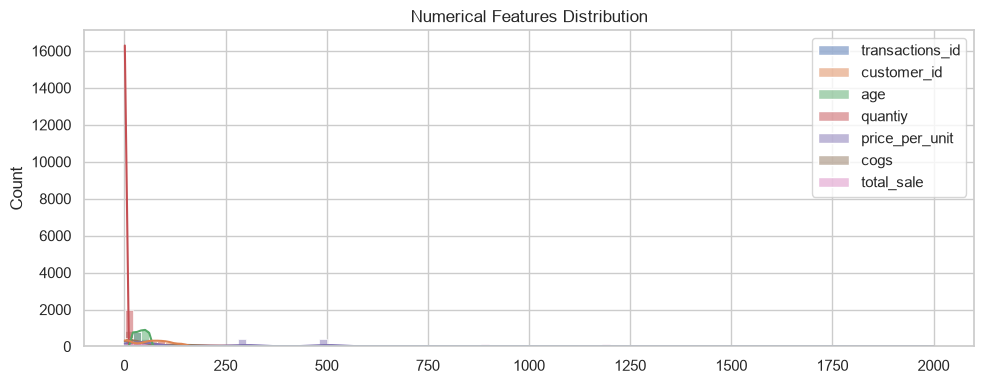

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.figure(figsize=(10, 4))
numeric_df = df.select_dtypes(include=[np.number])
sns.histplot(numeric_df, kde=True)
plt.title("Numerical Features Distribution")
plt.tight_layout()
plt.show()

Updated Column Names: ['transactions_id', 'sale_date', 'sale_time', 'customer_id', 'gender', 'age', 'category', 'quantity', 'price_per_unit', 'cogs', 'total_sale']


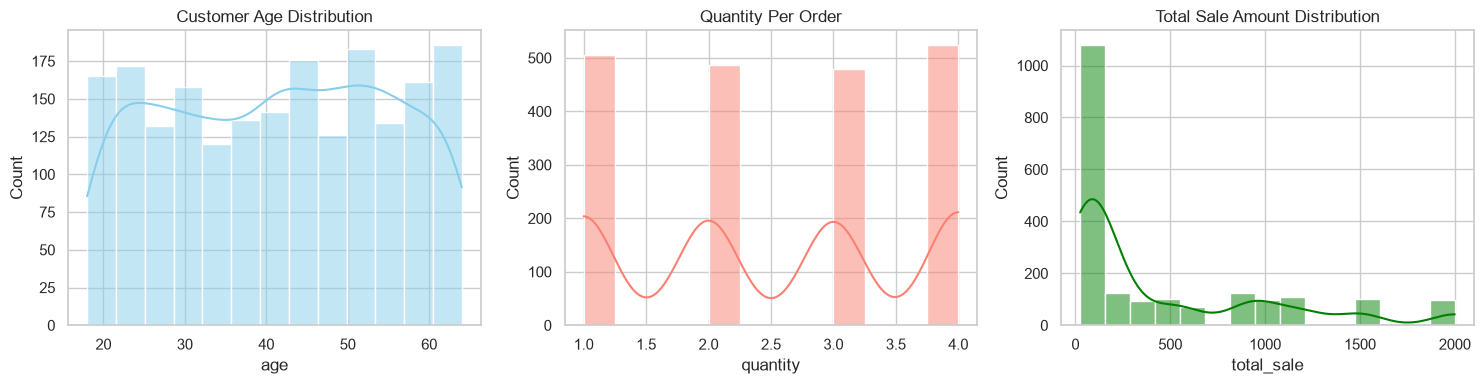

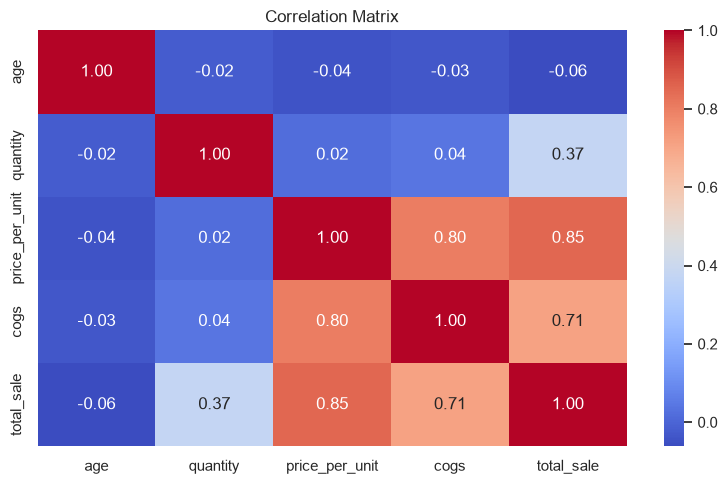

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Standardize column names (lowercase & remove extra spaces)
df.columns = df.columns.str.strip().str.lower()

# 2. Rename specific columns to fix spelling errors
# Format: {"old_name": "new_name"}
df = df.rename(
    columns={"quantiy": "quantity", "price_per_": "price_per_unit"}
)

print("Updated Column Names:", df.columns.tolist())

# 3. Plot specific individual distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["age"], kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Customer Age Distribution")

sns.histplot(df["quantity"], kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Quantity Per Order")

sns.histplot(df["total_sale"], kde=True, ax=axes[2], color="green")
axes[2].set_title("Total Sale Amount Distribution")

plt.tight_layout()
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(8, 5))
numeric_cols = [
    c
    for c in ["age", "quantity", "price_per_unit", "cogs", "total_sale"]
    if c in df.columns
]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Task 1 - Insights & Business Recommendations

1. **Target Demographics**: Age is evenly spread across customers (20–60 years), meaning marketing campaigns should avoid overly narrow age targeting and focus on category-specific promotions[span_6](start_span)[span_6](end_span)[span_7](start_span)[span_7](end_span).
2. **Order Volume Strategy**: Order quantities are concentrated in specific units (1, 2, 3, 4). Implementing multi-buy bundle discounts can incentivize higher order volumes[span_8](start_span)[span_8](end_span)[span_9](start_span)[span_9](end_span).
3. **Revenue Drivers**: The total sale distribution shows a heavy concentration in lower order values with occasional high-value purchases. Loyalty programs should be designed to increase average basket size[span_10](start_span)[span_10](end_span)[span_11](start_span)[span_11](end_span).